# Paracetamol: torsional states, and the symmetry that merges them

`md_tools.analysis.t_hdbscan` partitions the torsional ensemble into density basins;
`t_symmetry` then asks which of those basins are the SAME conformer seen through a permutation of
chemically identical atoms, and merges only those.

**A cluster is a density basin, not a metastable state.** Nothing here looks at time. Two peaks
separated by a sampled region are two clusters whatever the barrier between them.

**Needs the analysis environment** (`scikit-learn`, `rdkit`): see
[Installing](../../../install.md#5-optional-the-analysis-environment).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parents[1] / "_analysis"))   # docs/tutorial/_analysis

import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md
import tutorial_data as td

# Where the runs are. NOT defaulted: see docs/tutorial/_analysis/tutorial_data.py.
# The resolved path is deliberately NOT printed. These notebooks are committed WITH
# their outputs, so an echoed absolute path would put one machine's layout into a
# published file -- which this project forbids, and which executing a notebook turns
# from a parameter into a stored string.
print("tutorial runs:", "found" if td.runs_root().is_dir() else "MISSING")

tutorial runs: found


In [2]:
PARA_TORSIONS = {"omega": (0, 1, 3, 4), "aryl": (1, 3, 4, 5), "phenol": (6, 7, 8, 17)}
names, quads = list(PARA_TORSIONS), list(PARA_TORSIONS.values())

In [3]:
from md_tools.analysis import t_hdbscan

cmd = td.solute("PARA-1us", stride=25)          # 4000 frames is plenty for three torsions
tors = md.compute_dihedrals(cmd, quads)
print(f"{tors.shape[0]} frames, {tors.shape[1]} torsions")

fit = t_hdbscan(tors, names=names).fit()
summary = fit.summary()
print(f"n_clusters = {summary['n_clusters']}")
print(f"masses     = { {k: round(v, 3) for k, v in summary['cluster_mass'].items()} }")
print(f"noise      = {summary['noise_mass']:.4f}")

4000 frames, 3 torsions


n_clusters = 4
masses     = {0: 0.281, 1: 0.274, 2: 0.233, 3: 0.21}
noise      = 0.0013


## Is one state a possible answer here?

`allow_single_cluster` defaults to **True** in md-tools, which is a deliberate departure from
sklearn's default. With it False, HDBSCAN's EOM selection refuses the root of the condensed tree,
so a UNIMODAL ensemble cannot come back as one state -- it is split into two or three with a
plausible mass split and nothing in the output saying one state was never a candidate.

Paracetamol is a small, rigid molecule, so it is exactly the kind of system where that would have
bitten. Check it both ways rather than trusting either default.

In [4]:
for flag in (True, False):
    s = t_hdbscan(tors, names=names, allow_single_cluster=flag).fit().summary()
    print(f"allow_single_cluster={flag!s:5s} -> {s['n_clusters']} clusters, "
          f"excluded_by_construction={s['single_cluster_excluded_by_construction']}")
for caveat in summary["caveats"]:
    print("-", caveat)

allow_single_cluster=True  -> 4 clusters, excluded_by_construction=False
allow_single_cluster=False -> 4 clusters, excluded_by_construction=True
- cluster labels are ordered by descending population; HDBSCAN's own numbering is arbitrary and unrelated between fits
- draw_agreement is PRECISION, not accuracy: it says the count is stable under resampling, not that a small state was seen. Check that settings.min_cluster_size >= settings.min_samples first
- min_vote is a BOUNDARY detector, not a density test: against a direct fit's own noise it recalls about 7 %
- a cluster is a density basin, NOT a metastable state; nothing here looks at time


The answer is the same either way here, so the structure is real rather than an artefact of the
default. Had it differed, the number to believe would be the one from `True` -- and the marginals
in the PMF notebook would settle it.

## Which basins are the same conformer

The four clusters are two torsions each taking two values. But the phenyl ring has a two-fold
axis: flipping it exchanges chemically identical atoms and changes no physics. `t_symmetry` finds
that operation from the molecular graph and tests whether it maps one cluster's JOINT
distribution onto another's.

In [5]:
from rdkit import Chem
from md_tools.analysis import load_torsion_json, load_cluster_torsion, TorsionSymmetry
import json, tempfile, os

mol = Chem.SDMolSupplier(str(td.run_dir("PARA-REST2") / "build/TYL.sdf"), removeHs=False)[0]

# The SDF's atom order and the trajectory's are NOT assumed equal -- verified by bond graph.
from md_tools.analysis import verify_atom_mapping
bonds = [(b[0].index, b[1].index) for b in cmd.topology.bonds]
elements = [a.element.symbol for a in cmd.topology.atoms]
mapping, why = verify_atom_mapping(mol, bonds, elements)
print("atom mapping:", "identity" if mapping == list(range(mol.GetNumAtoms())) else mapping)
print(" ", why)

atom mapping: identity
  identity verified: elements and the full bond graph agree under this mapping


In [6]:
definition = {"schema_version": 1, "indexing": "zero-based", "units": "radian",
              "torsions": [{"name": n, "atoms": list(q)} for n, q in PARA_TORSIONS.items()]}
path = pathlib.Path(tempfile.mkdtemp()) / "torsion_cv.json"
path.write_text(json.dumps(definition, indent=2))

torsion_idx = load_torsion_json(path, molecule=mol)
clusters = load_cluster_torsion(tors, fit.labels_, noise_label=-1, angle_unit="radian",
                                names=list(torsion_idx.names))
print("cluster labels:", clusters.cluster_labels, "| masses:", clusters.mass_table())

cluster labels: [0, 1, 2, 3] | masses: {'clusters': {0: 0.28125, 1: 0.27425, 2: 0.23325, 3: 0.21}, 'noise': 0.00125, 'sum': 1.0}


In [7]:
detector = TorsionSymmetry(mol, torsion_idx)
detector.fit(clusters, coordinates=cmd.xyz, atom_mapping=mapping)

print("operations distinct on these torsions:", len(detector.operations))
print("groups:", detector.cluster_groups)
for c in detector.comparisons:
    if c.evidence.get("role") == "transitivity-guard":
        continue
    print(f"  {c.a} vs {c.b}: {c.verdict:9s} op={c.operation} "
          f"E={c.energy if c.energy is None else round(c.energy, 4)}")

operations distinct on these torsions: 2
groups: [[0, 2], [1, 3]]
  0 vs 1: rejected  op=1 E=2.4336
  0 vs 2: accepted  op=1 E=-0.0008
  0 vs 3: rejected  op=1 E=2.5619
  1 vs 2: rejected  op=1 E=2.5663
  1 vs 3: accepted  op=1 E=-0.0001
  2 vs 3: rejected  op=1 E=2.4338
  0 vs 2: accepted  op=1 E=-0.0008
  1 vs 3: accepted  op=1 E=-0.0001


**Not all four merge.** The ring flip relates 0 to 2 and 1 to 3, but nothing relates those two
groups: one is the pairing where both torsions sit together, the other where they are opposite,
and those are genuinely different relative orientations. The tolerance is calibrated from the
within-cluster split-half variability of THESE data, not from a universal constant.

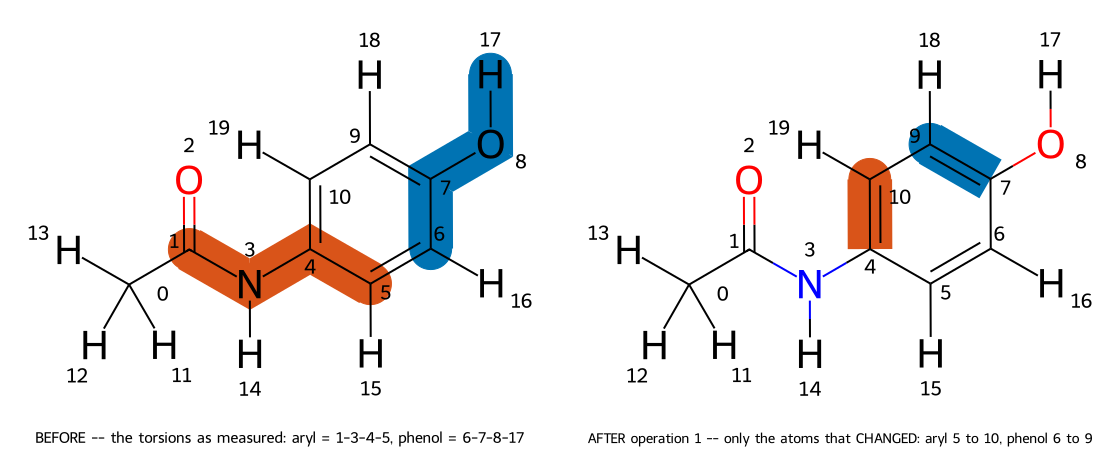

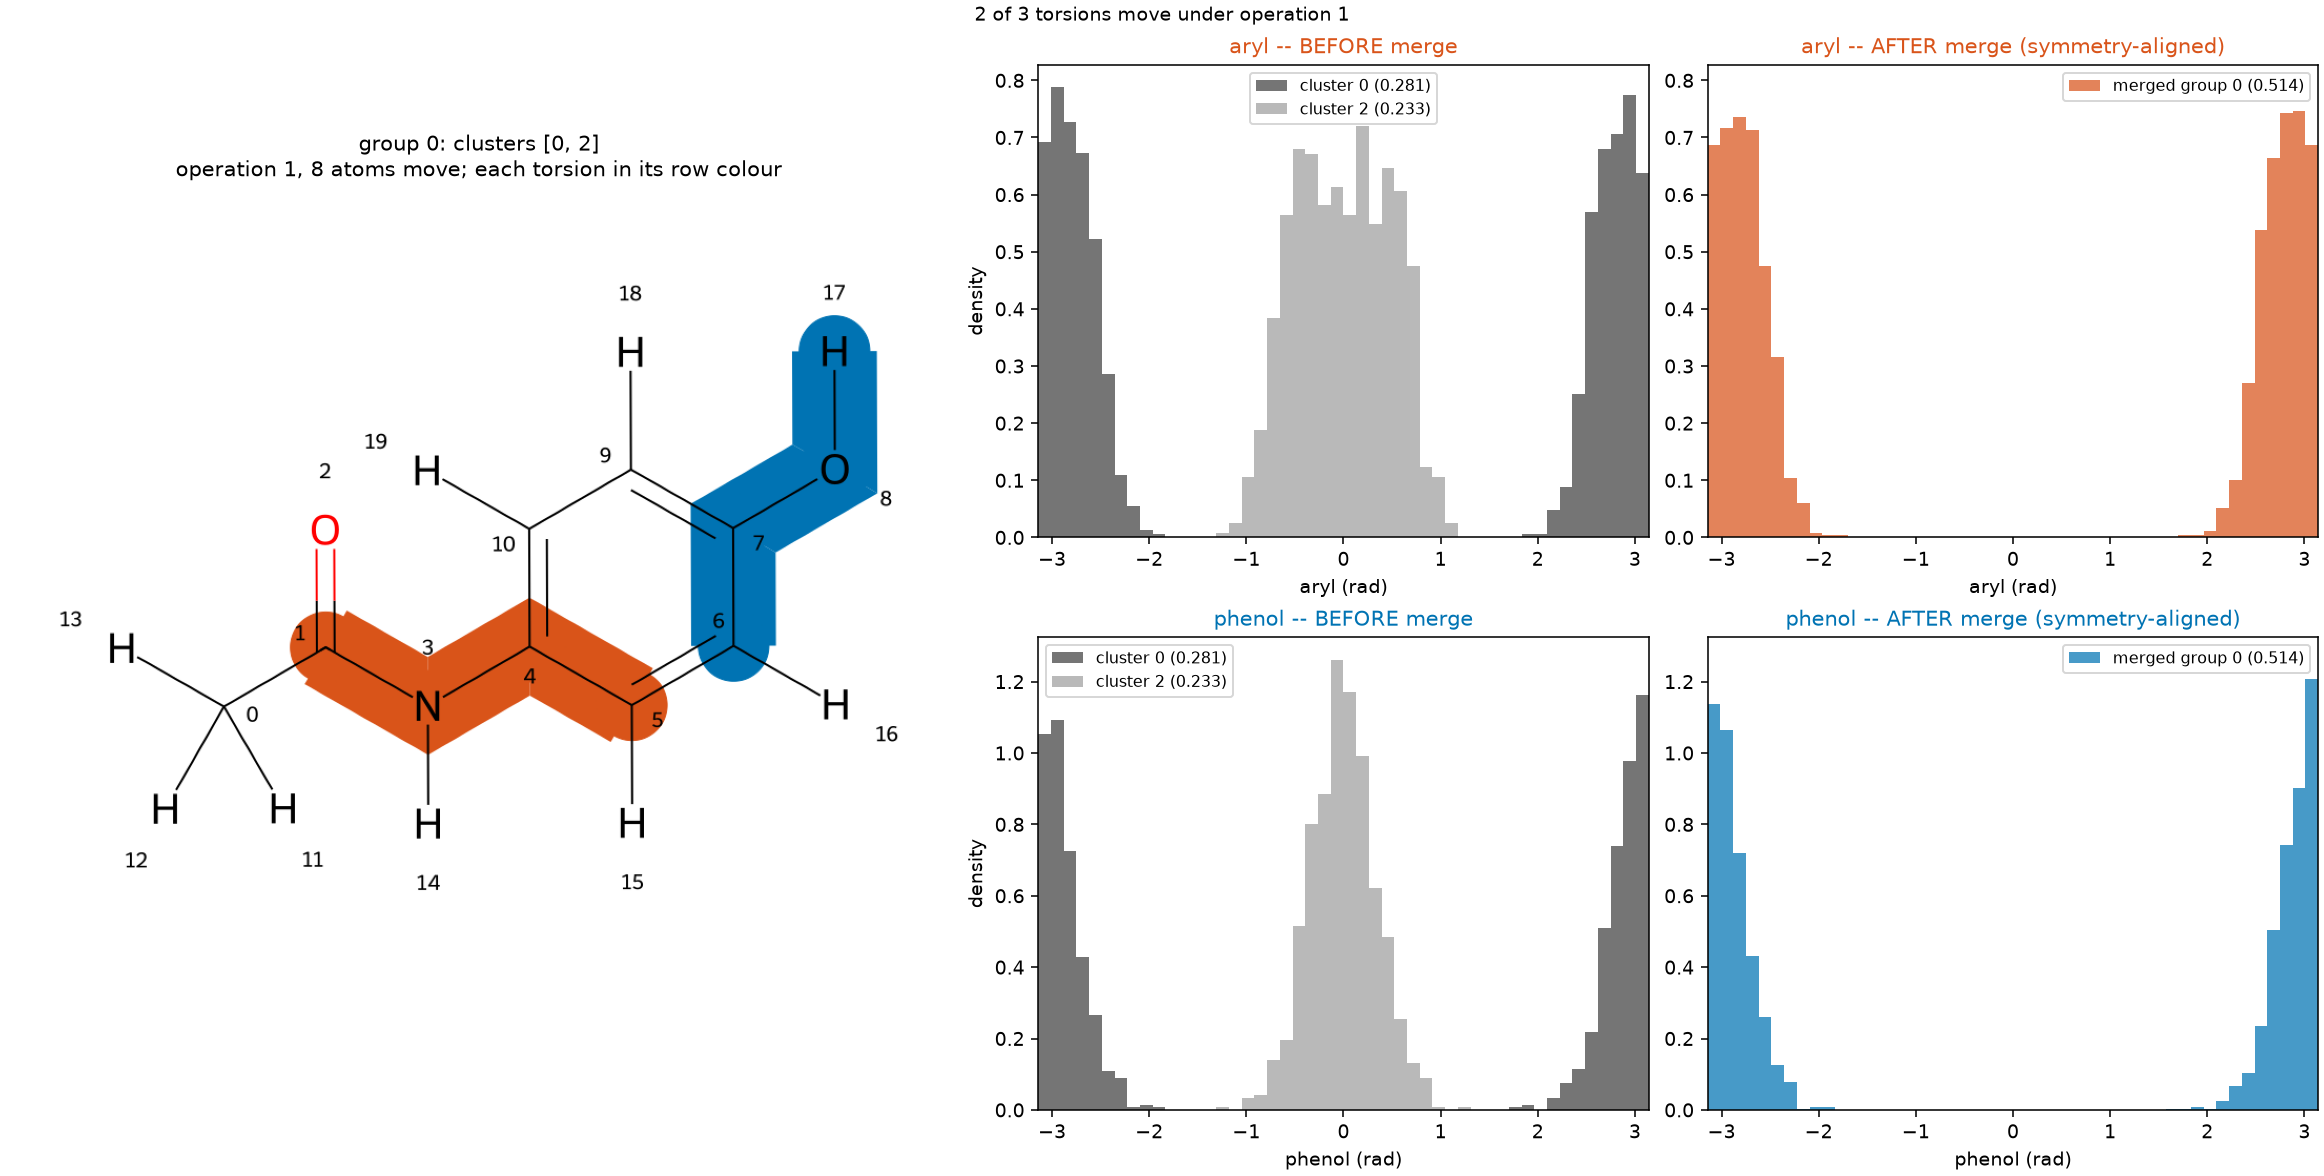

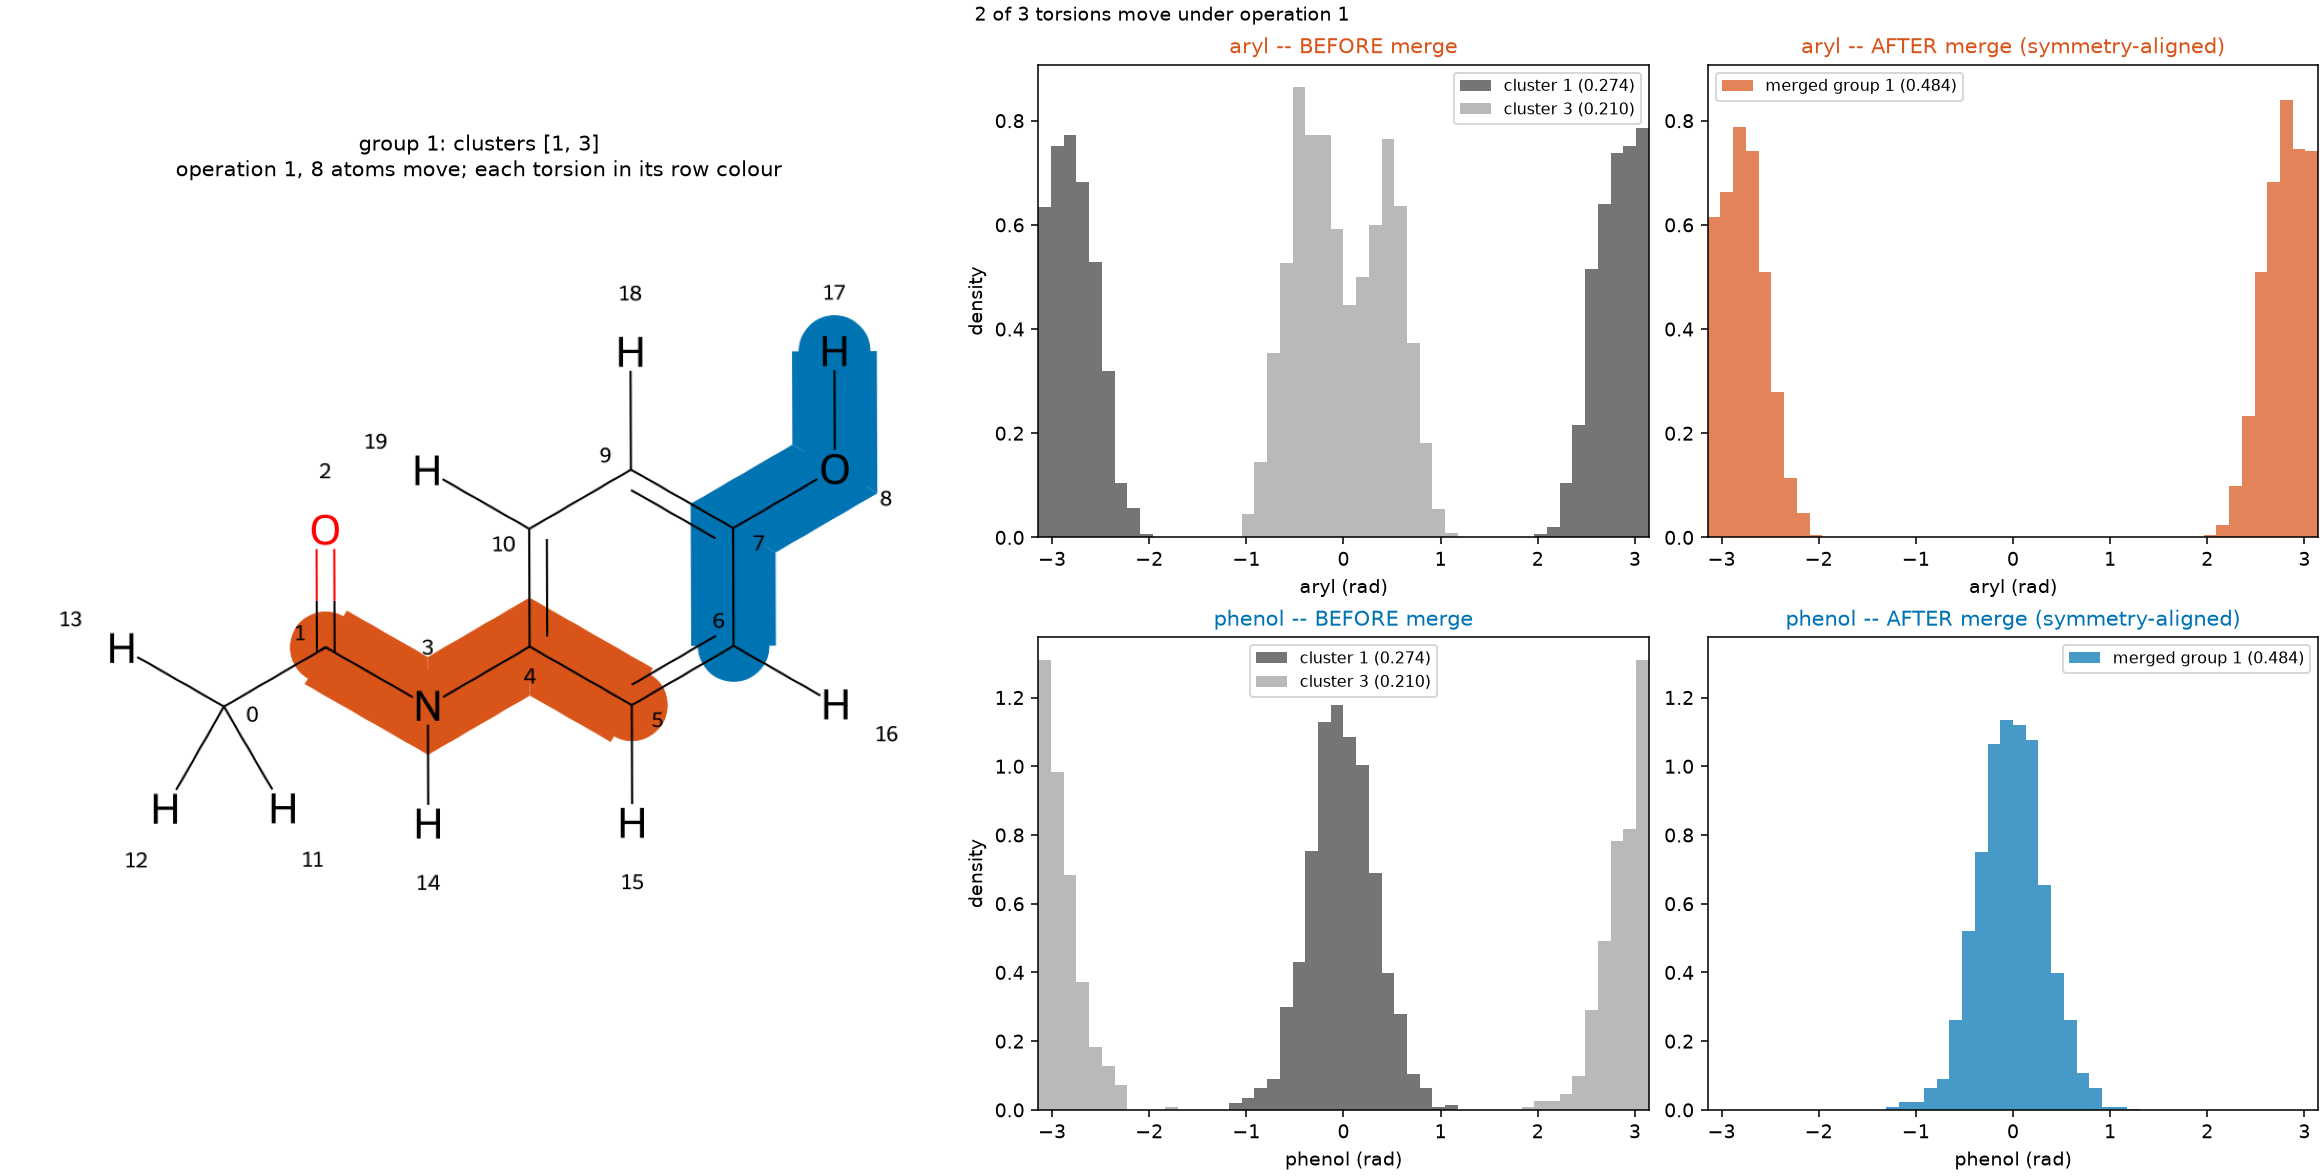

In [8]:
detector.draw_operation_effect(group=0, output="operation.png")
detector.draw_sym_group(0, output="group_0.png", cluster_torsions=clusters)
detector.draw_sym_group(1, output="group_1.png", cluster_torsions=clusters)

from IPython.display import Image, display
for name in ("operation.png", "group_0.png", "group_1.png"):
    display(Image(filename=name))

In [9]:
merged = detector.deduplicate(clusters)
print(json.dumps(merged.describe(), indent=2))
assert abs(sum(merged.masses.values()) + merged.noise_mass - 1.0) < 1e-9
print("\npopulations are conserved: merged masses + noise == 1 exactly")

{
  "groups": [
    [
      0,
      2
    ],
    [
      1,
      3
    ]
  ],
  "original_to_merged": {
    "0": 0,
    "1": 1,
    "2": 0,
    "3": 1
  },
  "masses": {
    "0": 0.5145,
    "1": 0.48424999999999996
  },
  "noise_mass": 0.00125,
  "operations_used": {
    "0": null,
    "1": null,
    "2": 1,
    "3": 1
  },
  "mass_sum_including_noise": 0.9999999999999999
}

populations are conserved: merged masses + noise == 1 exactly


Masses SUM across a merge; nothing is multiplied by the symmetry order. The group's order says
how many labels the ensemble was split into, not how much probability it holds -- and the noise
label keeps its own mass rather than being absorbed.

**A structural claim is not a thermodynamic one.** That two clusters are related by a graph
automorphism says their conformations are equivalent. If an atom-specific restraint or a REST2
region covers one side and not the other, the symmetry is broken even though the graph is
unchanged -- pass `broken_by=[...]` to record that, and it travels with every accepted pair.